In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import torch
from torch import nn
import numpy as np
from d2l import torch as d2l

ModuleNotFoundError: No module named 'tensorflow'

Generate 1-D Gaussian Dataset

In [ ]:
def gaussian_set_1d(size = 10, array_length = 1000, median_min = 0, median_max = 1, std_min = 0.1, std_max = 10):
    gaussian_set = []
    rng = np.random.default_rng(7)
    for i in range(size):
        median = rng.uniform(median_min, median_max)
        std = rng.uniform(std_min, std_max)
        print("median is: ", median, "std is: ", std)
        x = np.linspace(0, 1, array_length)
        y = np.exp(-0.5*(((x-median)/std)**2))
        #y = (std**-1)*((2*np.pi)**-0.5) * y #normalization?
        gaussian_set.append(y)
        plt.plot(y, 'o')
        plt.show()
    return gaussian_set

Add noise to said data set

In [ ]:
def add_noise(clean_gaussians, noise_median_min = 0, noise_median_max = 0, noise_std_min = 0.02, noise_std_max = 0.001):
    gaussian_set = []
    rng = np.random.default_rng(4)
    for clean_gaussian in clean_gaussians:
        noise = np.random.normal(0, noise_std_min, clean_gaussian.size)
        noise = clean_gaussian + noise
        gaussian_set.append(noise)
    return gaussian_set


Rewrite above to pytorch friendly format

In [ ]:
'''
class SyntheticRegressionData(d2l.DataModule):  #@save
    """Synthetic data for Gaussian regression."""
    @d2l.add_to_class  #@save
    def __init__(self, median, std, b, noise=0.01, num_train=1000, num_val=1000,
                 batch_size=32):
        super().__init__()
        self.save_hyperparameters()
        n = num_train + num_val
        self.X = torch.randn(n, 1)
        noise = torch.randn(n, 1) * noise
        #torch.exp(-0.5*(((X-median)/std)**2)) + self.b
        self.y = torch.exp(-0.5*(((self.X-median)/std)**2)) + b + noise
'''

'\nclass SyntheticRegressionData(d2l.DataModule):  #@save\n    """Synthetic data for Gaussian regression."""\n    @d2l.add_to_class  #@save\n    def __init__(self, median, std, b, noise=0.01, num_train=1000, num_val=1000,\n                 batch_size=32):\n        super().__init__()\n        self.save_hyperparameters()\n        n = num_train + num_val\n        self.X = torch.randn(n, 1)\n        noise = torch.randn(n, 1) * noise\n        #torch.exp(-0.5*(((X-median)/std)**2)) + self.b\n        self.y = torch.exp(-0.5*(((self.X-median)/std)**2)) + b + noise\n'

Get a set of gaussian, 

median is:  0.625095466604667 std is:  0.8972148288315658


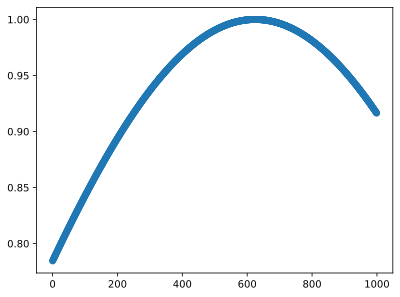

"\nfor example in examples:\n    plt.plot(example, 'o')\n    plt.show()\n"

In [ ]:
examples = gaussian_set_1d(1, 1000, 0, 1, 1e-5, 1)
examples = add_noise(examples)
#TODO: Partition them into different training set?
'''
for example in examples:
    plt.plot(example, 'o')
    plt.show()
'''


In [ ]:
'''
from torch.utils.data import TensorDataset, DataLoader#, NumpyDataModule
example = examples[0]
#dm = NumpyDataModule(X_np, y_np, batch_size=32)
x = torch.tensor(np.linspace(0, 1, 1000), dtype=torch.float32)
y = torch.tensor(example, dtype=torch.float32)
dataset = TensorDataset(x, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)
'''

'\nfrom torch.utils.data import TensorDataset, DataLoader#, NumpyDataModule\nexample = examples[0]\n#dm = NumpyDataModule(X_np, y_np, batch_size=32)\nx = torch.tensor(np.linspace(0, 1, 1000), dtype=torch.float32)\ny = torch.tensor(example, dtype=torch.float32)\ndataset = TensorDataset(x, y)\nloader = DataLoader(dataset, batch_size=32, shuffle=True)\n'

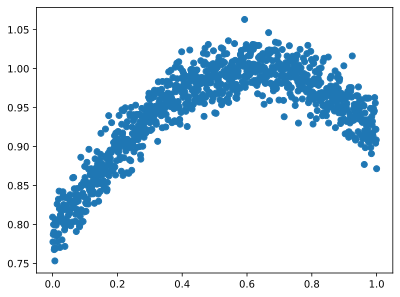

In [ ]:
from torch.utils.data import TensorDataset, DataLoader#, NumpyDataModule
class SimpleDataModule(d2l.DataModule):
    def __init__(self, X, y, batch_size=32):
        super().__init__()
        self.X = X
        self.y = y
        self.batch_size = batch_size

    def get_dataloader(self, train):
        dataset = TensorDataset(self.X, self.y)
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=train)

example = examples[0]
x = np.linspace(0, 1, 1000)
plt.plot(x, example, "o")
plt.show()
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(example, dtype=torch.float32)

dm = SimpleDataModule(x, y, batch_size=32)


First, a gaussian NN for regression, this neural network has only three parameter: mean and std, and bais

Define the Modal

In [ ]:
class GaussianRegressionScratch(d2l.Module):  #@save
    """The gaussian regression model implemented from scratch."""
    def __init__(self, num_inputs=2, lr=0.001, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.median = torch.normal(0, sigma, (1,), requires_grad=True)
        self.std = torch.normal(0, sigma, (1,), requires_grad=True) 
        #self.b = torch.zeros(1, requires_grad=True)

In [ ]:
@d2l.add_to_class(GaussianRegressionScratch)  #@save
def forward(self, X):
    return torch.exp(-0.5*(((X-self.median)/self.std)**2))# + self.b

Define Loss Function, L1 loss function is used

In [ ]:
@d2l.add_to_class(GaussianRegressionScratch)  #@save
def loss(self, y_hat, y):
    l = abs(y_hat - y) 
    return l.mean() #the loss is normalized

Define Optimization (Minibatch Stochastic Gradient Descent)

In [ ]:
class SGD(d2l.HyperParameters):  #@save
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

In [ ]:
@d2l.add_to_class(GaussianRegressionScratch)  #@save
def configure_optimizers(self):
    return SGD([self.median, self.std], self.lr)

In [ ]:
@d2l.add_to_class(d2l.Trainer)  #@save
def prepare_batch(self, batch):
    return batch

@d2l.add_to_class(d2l.Trainer)  #@save
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:  # To be discussed later
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

Start Trainig

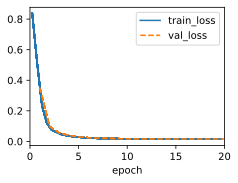

In [ ]:
model = GaussianRegressionScratch(lr=0.01)
trainer = d2l.Trainer(max_epochs=20)
trainer.fit(model, dm)

Visualization

In [ ]:
print(model.median, "\n")
print(model.std, "\n") 
#print(model.b)

tensor([0.6181], requires_grad=True) 

tensor([-0.8931], requires_grad=True) 

